In [1]:
from pynamicalsys import DiscreteDynamicalSystem as dds

# Define the symplectic map
ds = dds(model="4d symplectic map")

In [2]:
import numpy as np

# Initial conditions
u = [[0.5, 0, 0.5, 0], # Initial condition 1
     [3.0, 0, 0.5, 0]] # Initial condition 2

# Parameters for the symplectic map
eps1 = 0.5
eps2 = 0.1
xi = 0.001
parameters = [eps1, eps2, xi]

# Number of deviation vectors
k = [2, 3, 4]

# Total time for the simulation
total_time = 1000000

# Sample times for the LDI computation
sample_times = np.unique(np.logspace(np.log10(1), np.log10(total_time), 1000).astype(int))

# Compute the LDI for each initial condition and each k
LDIs = np.zeros((len(u), len(sample_times), len(k)))
for i in range(len(u)):
    for j in range(len(k)):
        print(i, j)
        ldi = ds.LDI(u[i], total_time, k[j], parameters=parameters, return_history=True, sample_times=sample_times)
        LDIs[i, :, j] = ldi

0 0


/opt/anaconda3/envs/pynamicalsys-dev/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",
/opt/anaconda3/envs/pynamicalsys-dev/lib/python3.12/site-packages/numba/core/utils.py:621: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


0 1
0 2
1 0
1 1
1 2


<Figure size 640x480 with 0 Axes>

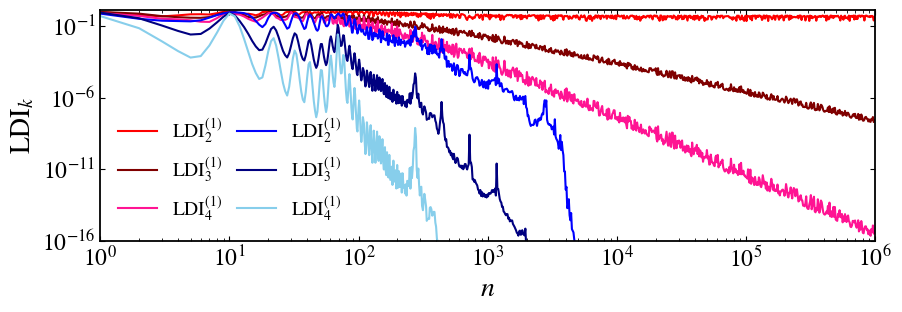

In [3]:
from pynamicalsys import PlotStyler
import matplotlib.pyplot as plt

# Create a plot styler
ps = PlotStyler(linewidth=1.5)
ps.apply_style()

# Create the figure and axis for the plot
fig, ax = plt.subplots(figsize=(10, 3))

# Plot the LDI for each initial condition and k
colors = [["red", "maroon", "deeppink"], ["blue", "navy", "skyblue"]]
for i in range(len(u)):
    for j in range(len(k)):
        ax.plot(sample_times, LDIs[i, :, j], label=rf"$\mathrm{{LDI}}_{k[j]}^{{(1)}}$", color=colors[i][j])

# Add a legend and set the limits and labels
ax.legend(ncol=2, frameon=False, columnspacing=0.75)
ax.set_ylim(1e-16, np.sqrt(2))
ax.set_xlim(1, total_time)
ax.set_xlabel("$n$")
ax.set_ylabel(r"$\mathrm{LDI}_k$")
ax.set_xscale('log')
ax.set_yscale("log")